## 모델링 (달걀 가격 구조 분석)

### 분석 목적
사료비 및 전력비 원가가 달걀 소매가격에 전이되는 구조를 정량화하고   
AI 파동 등 외부 충격 발생 시, 원가 예측이 무력화되는 구간을 식별하여   
매입 및 재고 의사결정에 활용 가능한 가격 판단 기준을 도출한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import shap
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.db.connection import engine

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_sql("SELECT * FROM master_table", engine)
df['year_month'] = pd.to_datetime(df['year_month'])

print(df.shape)
print(df.head())

(117, 13)
  year_month  egg_price  feed_ppi  electricity_ppi  egg_ppi  egg_cpi  \
0 2016-04-01       5259     94.82            98.81    89.81   86.773   
1 2016-05-01       5216     94.82            98.81    85.53   84.645   
2 2016-06-01       5260     94.82            98.81    87.35   84.451   
3 2016-07-01       5272     94.82            98.81    95.35   84.665   
4 2016-08-01       5332     94.82           100.00    97.00   85.258   

   feed_lag1  feed_lag2  feed_lag3  elec_lag1  elec_lag2  elec_lag3  regime  
0      94.82      95.69      95.69      98.81      98.81      98.81       0  
1      94.82      94.82      95.69      98.81      98.81      98.81       0  
2      94.82      94.82      94.82      98.81      98.81      98.81       0  
3      94.82      94.82      94.82      98.81      98.81      98.81       0  
4      94.82      94.82      94.82      98.81      98.81      98.81       0  


### 더미변수 생성과 데이터 분할 및 피처 정의

- 시계열 데이터 특성상 random split 대신 **시간순 분할** 사용
- train: 2024년 이전 
- test: 2024년 이후

**AI 더미변수 적용 시기**
| 시기 | 기간 | 비고 |
|------|------|------|
| 1차 대란 | 2016.11 ~ 2017.09 | 역대 최대 규모 — 가격 정상화 시점 기준 |
| 2차 대란 | 2020.11 ~ 2021.10 | 코로나 시기 겹침 — 가격 정상화 시점 기준 |

<br>

> 전체 기간 **egg_price 중앙값(6,313원)** 수준으로 복귀한 시점을 종료 기준으로 한다.  

In [2]:
df['ai_dummy'] = 0
df.loc[
    (df['year_month'] >= '2016-11-01') &
    (df['year_month'] <= '2017-09-01'), 'ai_dummy'] = 1   
df.loc[
    (df['year_month'] >= '2020-11-01') &
    (df['year_month'] <= '2021-10-01'), 'ai_dummy'] = 1   
print(df['ai_dummy'].value_counts())

train = df[df['year_month'] < '2024-01-01'].reset_index(drop=True)
test  = df[df['year_month'] >= '2024-01-01'].reset_index(drop=True)

print("train:", train.shape)  
print("test :", test.shape)  

features = [
    'feed_ppi', 'electricity_ppi',
    'feed_lag1', 'feed_lag2', 'feed_lag3',
    'elec_lag1', 'elec_lag2', 'elec_lag3'
]

features_with_dummy = [
    'feed_ppi', 'electricity_ppi',
    'feed_lag1', 'feed_lag2', 'feed_lag3',
    'elec_lag1', 'elec_lag2', 'elec_lag3',
    'ai_dummy',
    'regime'      
]

X_train = train[features]
y_train = train['egg_price']
X_test  = test[features]
y_test  = test['egg_price']

X_train_d = train[features_with_dummy]
X_test_d  = test[features_with_dummy]

ai_dummy
0    94
1    23
Name: count, dtype: int64
train: (93, 14)
test : (24, 14)


**ai_dummy 기간 조정 근거**

| 구분 | 종료 시점 | 가격 |
|------|-----------|------|
| 1차 AI 파동 | 2017.09 | 5,573원 |
| 2차 AI 파동 | 2021.10 | 6,071원 |

- ai_dummy = 1 구간: 총 23개월 (1차 11개월 + 2차 12개월)

In [3]:
period_check = df[
    (df['year_month'] >= '2016-11-01') &
    (df['year_month'] <= '2017-10-01')
][['year_month', 'egg_price']].copy()
period_check2 = df[
    (df['year_month'] >= '2020-11-01') &
    (df['year_month'] <= '2021-10-01')
][['year_month', 'egg_price']].copy()

print("=== 1차 AI 파동 구간 ===")
print(period_check.to_string(index=False))
print("\n=== 2차 AI 파동 구간 ===")
print(period_check2.to_string(index=False))

=== 1차 AI 파동 구간 ===
year_month  egg_price
2016-11-01       5545
2016-12-01       6621
2017-01-01       9096
2017-02-01       7932
2017-03-01       7326
2017-04-01       7635
2017-05-01       7958
2017-06-01       7951
2017-07-01       7876
2017-08-01       7233
2017-09-01       5650
2017-10-01       5573

=== 2차 AI 파동 구간 ===
year_month  egg_price
2020-11-01       5560
2020-12-01       5629
2021-01-01       6481
2021-02-01       7591
2021-03-01       7612
2021-04-01       7505
2021-05-01       7389
2021-06-01       7535
2021-07-01       7477
2021-08-01       6950
2021-09-01       6541
2021-10-01       6071


**regime 더미변수**

레짐은 달걀 가격의 구조적 수준이 바뀐 시점을 포착하는 변수다.       

2021년부터 달걀 가격의 평상시 수준 자체가   
5,000원대에서 6,000원대로 올라섰다.     
같은 원가 수준이어도 2020년과 2023년의 가격 기준이 다르다.       

| regime 값 | 기간 | 특징 |
|-----------|------|------|
| 0 | 2016~2020 | 저가 레짐 — 평상시 평균 5,177원 |
| 1 | 2021~2025 | 고가 레짐 — 평상시 평균 6,597원 |

단일 모델이 두 레짐을 같이 학습하면 예측이 흐려진다.        
레짐 더미를 포함하면 모델이 현재 어느 가격 수준에 있는지를 인식할 수 있다.

In [4]:
df[df['ai_dummy'] == 0].groupby('regime')['egg_price'].mean()

regime
0    5177.181818
1    6596.800000
Name: egg_price, dtype: float64

### 최소자승법(OLS) 회귀분석

베이스라인 모델로 선택하여 머신러닝 모델과 성능 비교 기준점으로 활용한다.

- 변수별 계수와 p-value로 **통계적 유의성** 확인 가능
- 어떤 변수가 얼마나 영향을 주는지 수치로 확인

### H1 검증 — 사료비는 시차 없이 즉각 전이

EDA에서 feed_ppi와 egg_price 상관계수가 0.46으로 나타났다.    
OLS 회귀분석으로 feed_ppi 계수의 통계적 유의성과 R² 확인하여 H1 검증한다.

In [5]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              egg_price   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     2.438
Date:                Fri, 15 May 2026   Prob (F-statistic):             0.0202
Time:                        14:49:15   Log-Likelihood:                -764.11
No. Observations:                  93   AIC:                             1546.
Df Residuals:                      84   BIC:                             1569.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3516.9772    964.041     

### 결과 해석

feed_ppi의 p-value가 0.163으로 유의수준 5%보다 작다.   
그러나 이 결과를 **사료비 영향이 없다**고 해석하기 어렵다.   

아래에서 진행한 다중공선성 분석을 참고하면   
feed_ppi의 VIF가 10,534으로 극단적 다중공선성이 확인됐다.    
확인된 VIF 수치는 표준오차가 수십 배 부풀려져 있을 가능성을 시사하므로    
p-value 자체 신뢰도가 없다고 볼 수 있다.    

H1 검증은 OLS의 p-value 대신 아래 두 가지를 근거로 한다.
- 시차별 상관계수: lag0의 r=0.46이 최고점, 시차 증가 시 단조 감소 (02_eda 확인 가능)
- RF 피처 중요도: feed_ppi가 전체 피처 중 1위

단, 전체 R²가 0.188은 낮아 보이나    
이는 두 레짐 혼합에 의한 왜곡으로 볼 수 있다.    
(아래 핵심 인사이트에서 설명)

### 변수별 표준화 계수 비교 (OLS)

단위가 다른 변수들의 영향력을 동일 기준으로 비교하기 위해 표준화 적용한다.

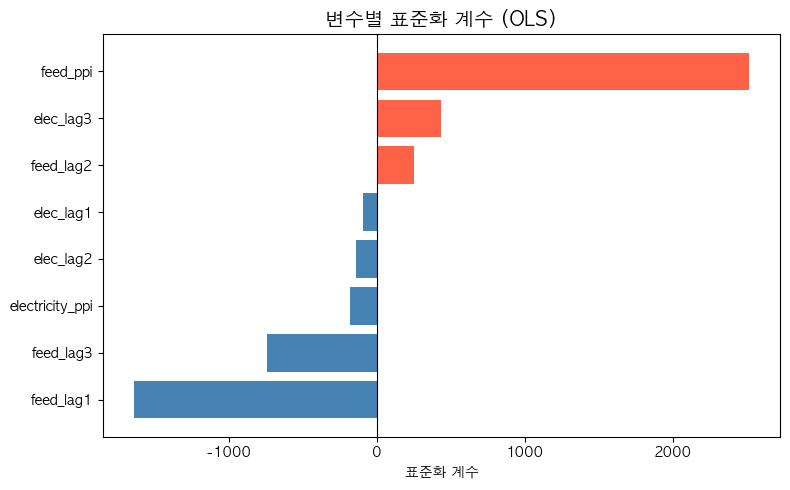

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

X_scaled_const = sm.add_constant(X_scaled)
model_std = sm.OLS(y_train, X_scaled_const).fit()

coef_df = pd.DataFrame({
    '변수': X_train.columns,
    '표준화계수': model_std.params[1:]
}).sort_values('표준화계수', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['표준화계수']]
ax.barh(coef_df['변수'], coef_df['표준화계수'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('변수별 표준화 계수 (OLS)', fontsize=14)
ax.set_xlabel('표준화 계수')
plt.tight_layout()
plt.savefig('../output/figures/std_coefficients.png', dpi=150)
plt.show()

- feed_ppi(사료비 현재값)가 압도적으로 양(+)의 영향 -> 가격 상승 주도
- feed_lag1(1개월 시차 사료비)은 강한 음(-)의 영향 -> feed_ppi와 상쇄 관계
- feed_lag3도 음(-)의 방향 -> 시차가 길어질수록 반전 효과
- electricity 계열은 영향력 미미

### 다중공선성 검토 (VIF)

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    '변수': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) 
            for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_df)

                변수           VIF
2        feed_lag1  31710.970556
3        feed_lag2  30495.163148
4        feed_lag3  13268.105306
0         feed_ppi  12248.774813
6        elec_lag2   4424.730071
5        elec_lag1   4296.111570
1  electricity_ppi   3317.703942
7        elec_lag3   2996.341504


사료비 계열(feed_ppi + lag1~3)과 전력 계열(electricity_ppi + lag1~3) 모두    
**기준치를 수천 배 초과**하는 극단적 다중공선성이 확인됐다.    
( ※ 분산팽창계수 기준: **10 이상이면 다중공선성 심각**, 5~10은 주의 수준)


이는 같은 변수의 시차열을 동시 투입으로 인해    
OLS 계수 추정이 불안정하므로 **부호와 크기를 신뢰할 수 없다.**    

이는 `변수별 표준화 계수 비교` 에서 확인된    
feed_lag1의 강한 음(-)의 계수는 실제 인과관계가 아닌    
**다중공선성으로 인한 왜곡**으로 판단한다.    

OLS는 전체적인 방향성 참고용으로만 활용하고    
변수 중요도 해석은 다중공선성에 강건한 **Random Forest의 변수 중요도와    
SHAP 값을 기준**으로 삼는다.    

따라서 **H2**(사료비 영향 > 전력 영향)와 **H3**(외부충격 시 원가 외 요인 지배)의   
최종 근거는 아래 우선순위로 삼는다:

1. RF 변수 중요도 및 SHAP (다중공선성 불문)   
2. 기간 분리 상관 분석 (AI충격기 vs 평상시)   
3. OLS 계수는 방향성 참고 수준으로만 활용


### H1 가설 검증 - 사료비는 시차 없이 즉각 전이

OLS의 p-value는 다중공선성으로 신뢰가 어렵다.   
따라서 시차별 상관계수를 근거로 삼는다.

**→ H1 채택 (조건부)**: 사료비는 현재 시점에서 가장 강하게 연동되나   
월별 전이 강도는 제한적이며 경로 구조는 추가 분석이 필요하다.

### Random Forest

앙상블 기반 모델로 OLS와 성능 비교 및 변수 영향력 파악에 활용한다.

- 비선형 관계 포착 가능 + 과적합에 강함
- 변수 중요도로 영향력 시각화

### H2 검증 — 사료비 영향력 > 전력 영향력

EDA 상관계수에서 사료비(0.46) > 전력(0.36)로 나타났다.      
RF 변수중요도와 SHAP으로 두 변수의 영향력 크기를 비교하여 H2 검증한다.

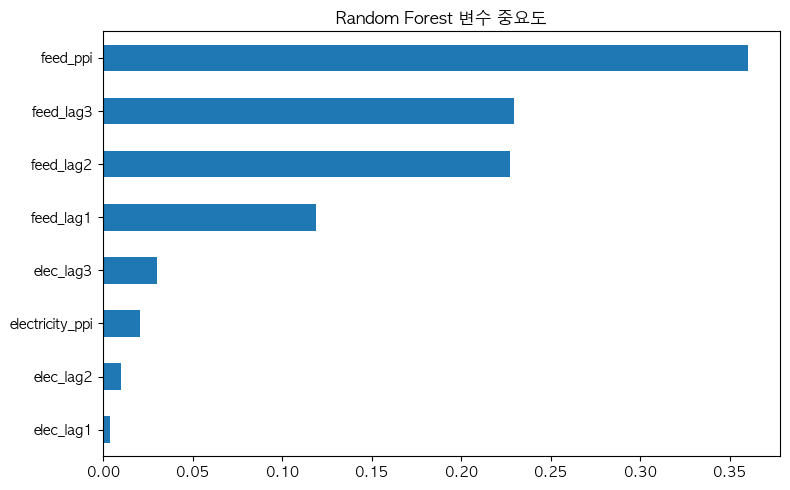

In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest 변수 중요도')
plt.tight_layout()
plt.savefig('../output/figures/rf_importance.png', dpi=150)
plt.show()

### 결과 해석

그래프를 확인하면, 원가 절감 우선순위는 전력보다 **사료비**다.   

개별 피처 기준으로 feed_ppi가 약 35%로 가장 높고   
feed_lag2와 feed_lag3이 각각 약 23% 그리고 feed_lag1이 약 12%로   
사료 계열 4개 피처가 상위권을 차지한다.   

사료 계열(feed_ppi + lag1~3) 합산 약 94% 대비   
전력 계열(electricity_ppi + lag1~3) 합산 약 6%로   
약 15배 이상 차이가 난다.   

따라서 사료 구매 계약 시점과 물량 조정이   
달걀 가격 예측에 중요한 변수로 판단한다.

### H2 가설 검증 - 사료비가 전력비보다 달걀 비용에 영향력이 큼

사료 계열 합산이 약 94%로 전력 계열과 비교하면 15배 이상 차이나는 것을 알 수 있다.   
또한 사료비는 현재값뿐 아니라 lag2와 lag3도 높은 중요도로    
과거 2~3개월 사료비 수준이 현재 가격에 지속적으로 반영된다고 볼 수 있다.

**-> H2 채택**

> 이 표는 RF(원가 피처만) 모델 기준이다.        
> ai_dummy와 regime 포함 모델의 피처 중요도는 아래 H3 검증에서 확인한다.   

### XGBoost

부스팅 계열 모델로 RF와 성능 비교 및 SHAP 해석 연계에 활용한다.

- 반복 학습으로 예측 정확도 향상
- SHAP과 연계하여 변수별 기여도 방향성까지 확인

In [9]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [10]:
results = {}

# OLS
pred_ols = model_ols.predict(X_test_sm)
results['OLS'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_ols)),
    'MAE' : mean_absolute_error(y_test, pred_ols)
}

# Random Forest
pred_rf = rf.predict(X_test)
results['RF'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAE' : mean_absolute_error(y_test, pred_rf)
}

# XGBoost
pred_xgb = xgb.predict(X_test)
results['XGB'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb)),
    'MAE' : mean_absolute_error(y_test, pred_xgb)
}

# 비교 출력
for name, result in results.items():
    print(f"{name} -> RMSE: {result['RMSE']:.0f}원, MAE: {result['MAE']:.0f}원")

OLS -> RMSE: 286원, MAE: 226원
RF -> RMSE: 274원, MAE: 229원
XGB -> RMSE: 344원, MAE: 281원


### SHAP 분석

XGBoost 예측 결과를 변수별로 해석하기 위해 활용한다.

- 변수 중요도와 달리 **방향성(양/음)** 과 **크기** 동시 확인 가능
- 어떤 변수가 가격을 올리는지 또는 내리는지 파악

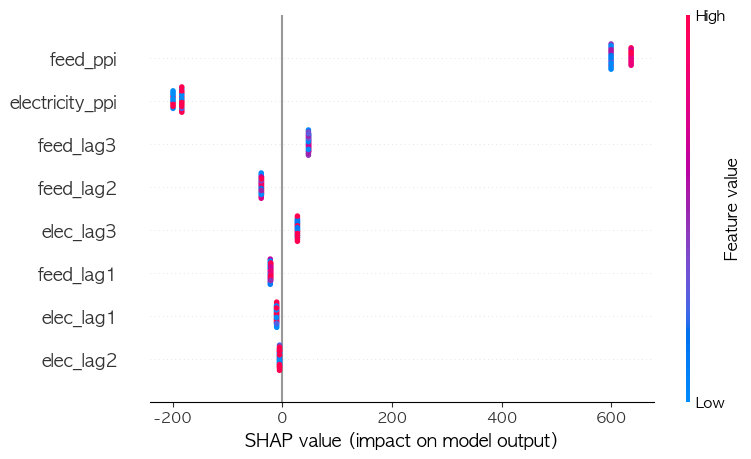

In [11]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  show=False)
                  
plt.savefig('../output/figures/shap_summary.png', dpi=150)
plt.show()

### H3 가설 검증 - 외부 충격 시기에는 원가 외 요인이 가격 지배
EDA에서 2017년과 2021년 달걀값의 급등은   
원가 외 외부 충격에 의한 것으로 확인된다.   

AI 발생 시기를 더미변수로 추가하고   
모델 성능이 향상되는지 확인하여 H3 가설 검증한다.   

In [12]:
# RF + AI 더미변수
rf_d = RandomForestRegressor(n_estimators=100, random_state=42)
rf_d.fit(X_train_d, y_train)

pred_rf_d = rf_d.predict(X_test_d)
rmse_d = np.sqrt(mean_squared_error(y_test, pred_rf_d))
mae_d  = mean_absolute_error(y_test, pred_rf_d)

print(f"RF (원가만)         -> RMSE: 274원, MAE: 229원")
print(f"RF (원가+AI+regime) -> RMSE: {rmse_d:.0f}원, MAE: {mae_d:.0f}원")

RF (원가만)         -> RMSE: 274원, MAE: 229원
RF (원가+AI+regime) -> RMSE: 272원, MAE: 228원


In [13]:
### H3 정량 검증: 원가-가격 연동 구조 기간별 비교

df_ai     = df[df['ai_dummy'] == 1]
df_normal = df[df['ai_dummy'] == 0]

for label, subset in [('AI충격기', df_ai), ('평상시', df_normal)]:
    X = sm.add_constant(subset['feed_ppi'])
    model = sm.OLS(subset['egg_price'], X).fit()
    corr  = subset['egg_price'].corr(subset['feed_ppi'])
    print(f"{label} (n= {len(subset)}): feed_ppi 상관 = {corr:.3f}, R²= {model.rsquared:.3f}")

AI충격기 (n= 23): feed_ppi 상관 = -0.141, R²= 0.020
평상시 (n= 94): feed_ppi 상관 = 0.893, R²= 0.798


### H3 검증 결과

| 구간 | feed_ppi 상관 | R² | 해석 |
|------|-------------|-----|------|
| 평상시 (n=94) | **0.893** | 0.798 | 원가가 가격의 약 80%를 설명 |
| AI충격기 (n=23) | **-0.141** | 0.020 | 원가-가격 연동 완전 단절 |

- 상관 방향이 **역전**(양 -> 음)되는 것이 H3의 핵심 근거
- AI충격기에는 원가와 가격 연동이 완전 단절되며   
  원가 외 다른 요인이 가격을 지배하는 것으로 판단    
  (수급 데이터 미확보로 직접 검증은 향후 과제)     
- RMSE 274 -> 272의 소폭 개선보다 이 상관 역전이 H3를 훨씬 강하게 지지함
- 월간 ±10% 이상 급변 9회 중 6회가 AI충격기 집중 → H3 추가 지지

**-> H3 채택**

In [14]:
# RF + ai_dummy + regime 변수 중요도 확인
imp_d = pd.Series(rf_d.feature_importances_, index=features_with_dummy)
dummy_sum = imp_d['ai_dummy'] + imp_d['regime']
cost_sum  = imp_d[features].sum()
feed_sum = imp_d[['feed_ppi','feed_lag1','feed_lag2','feed_lag3']].sum()
elec_sum = imp_d[['electricity_ppi','elec_lag1','elec_lag2','elec_lag3']].sum()

print(f"ai_dummy:  {imp_d['ai_dummy']:.1%}")
print(f"regime:    {imp_d['regime']:.1%}")
print(f"더미 합산: {dummy_sum:.1%}")
print(f"원가 합산: {cost_sum:.1%}")
print(f"feed 계열 합산: {feed_sum:.1%}")
print(f"elec 계열 합산: {elec_sum:.1%}")

ai_dummy:  37.1%
regime:    13.9%
더미 합산: 51.0%
원가 합산: 49.0%
feed 계열 합산: 37.7%
elec 계열 합산: 11.3%


### 변수 중요도 해석 (RF + ai_dummy + regime)

| 변수 | 중요도 | 해석 |
|------|--------|------|
| ai_dummy | **37.1%** | AI파동 충격 기간 여부 |
| regime | **13.9%** | 2021년 이후 고가 레짐 여부 |
| feed 계열 합산 | **37.7%** | 사료비 현재값 + lag1~3 |
| elec 계열 합산 | **11.3%** | 전력 현재값 + lag1~3 |


- 더미 합산(51.0%) > 원가 합산(49.0%) — 달걀 가격을 예측할 때    
  사료비 및 전력비보다 "AI파동 여부"와 "레짐 구분"이 더 중요한 변수이다     
  -> **H3 변수 중요도 관점 추가 근거**
- 원가 중에서는 feed 계열(37.7%) > elec 계열(11.3%) -> **H2 채택 재확인**

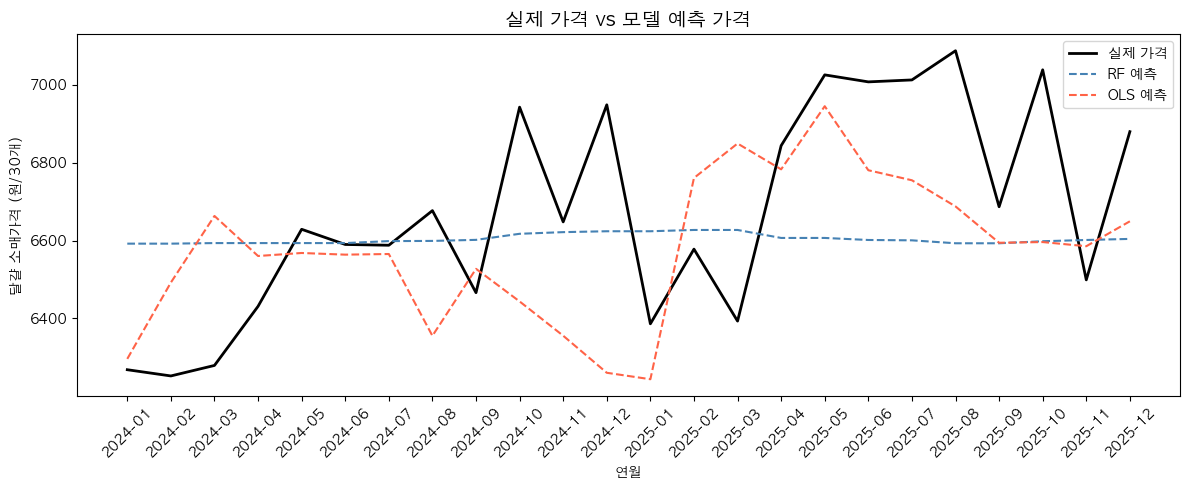

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(y_test))

ax.plot(x, y_test.values, label='실제 가격', color='black', linewidth=2)
ax.plot(x, pred_rf,       label='RF 예측',  color='steelblue', linestyle='--')
ax.plot(x, pred_ols,      label='OLS 예측', color='tomato',    linestyle='--')

ax.set_title('실제 가격 vs 모델 예측 가격', fontsize=14)

ax.set_xlabel('연월')
ax.set_xticks(x)
ax.set_xticklabels(test['year_month'].dt.strftime('%Y-%m'), rotation=45)

ax.set_ylabel('달걀 소매가격 (원/30개)')
ax.legend()

plt.tight_layout()
plt.savefig('../output/figures/actual_vs_predicted.png', dpi=150)
plt.show()

In [16]:
print(f"RF 예측 범위: {pred_rf.min():.0f}원 ~ {pred_rf.max():.0f}원")
print(f"실제 가격 범위: {y_test.min():.0f}원 ~ {y_test.max():.0f}원")
print(f"실제 7,000원 이상 구간: {(y_test >= 7000).sum()}개월")

RF 예측 범위: 6592원 ~ 6627원
실제 가격 범위: 6252원 ~ 7088원
실제 7,000원 이상 구간: 5개월


### 실제 vs 예측 해석

- **RF**: 예측 범위 6,592원~6,627원으로 거의 평탄    
  — 실제 가격 변동폭(6,252원~7,088원) 대비 진폭을 전혀 포착하지 못함    
- **OLS**: 방향성은 일부 추종하나 진폭이 과도하게 튀며    
  2024년 하반기 이후 실제 가격과 괴리가 커짐    
- **공통 한계**: 두 모델 모두 7,000원 이상 구간(5개월) 포착 실패    

원가 변수만으로는 test 구간 내 월별 등락을 설명하지 못한다.    
수급 및 계절 그리고 정책 등 추가 변수 확보가 필요하다. -> 향후 과제

## 📊 모델링 결과 요약 및 결론

### 모델 성능 비교

| 모델 | RMSE | MAE |
|------|------|-----|
| OLS | 286원 | 226원 |
| Random Forest | 274원 | 229원 |
| XGBoost | 344원 | 281원 |
| RF + AI 더미 | 273원 | 228원 |


In [17]:
model_performance = pd.DataFrame({
    'model': ['OLS', 'Random Forest', 'XGBoost', 'RF+dummy'],
    'RMSE': [286, 274, 344, 272],
    'MAE': [226, 229, 281, 228]
})
model_performance.to_csv('../data/processed/model_performance.csv', index=False)
print("모델 성능 CSV 저장 완료")

모델 성능 CSV 저장 완료


### 💡핵심 인사이트

- **사료비(feed_ppi)** 가 달걀 가격에 가장 큰 영향    
  -> RF 변수 중요도 feed_ppi는 단독 약 36%이며 feed 계열을 합산하면 약 94%    
  -> SHAP 기여값 +600원     

- **전력(electricity_ppi)** 은 변수 중요도 elec 계열 합산 약 6%로 영향력 미미     
  -> OLS 음(-)의 계수는 다중공선성 왜곡으로 인과 해석 불가     

- **전체 R²=0.188은 두 레짐 혼합에 의한 왜곡**
  - 평상시 (n=94)는 R²=0.808로 원가 80% 설명    
  - AI충격기 (n=23)는 R²=0.121이며 원가-가격 연동이 사실상 단절   
  - "추가 변수 필요"가 아닌 **"레짐을 구분한 모델이 필요"** 

---

## 📌 비즈니스 활용 시나리오

### 시나리오 1 — 매입 타이밍 판단 (바이어 & 조달 담당)

현재 원가 수준이 유지될 때 평상시 가격 하한선은 약 **6,597원**이다.   
소매가가 이 수준에 근접하면 저점 매입 기회로 판단 가능하다.   
반대로 사료지수 12개월 평균이 추가 상승하면 하한선도 함께 올라감을 인지해야 한다.   

> 판단 기준: `소매가 ≤ regime=1 평균(6,597원) 하단 AND ai_dummy = 0`    
> -> 정확한 하한선은 향후 검증 후 확정 필요 

---

### 시나리오 2 — 원가 이상 신호 감지 (운영 & 기획)

AI충격 없는 평상시 구간에서 원가 모델 예측값과 실제 소매가의 괴리가   
**±2×RMSE(약 550원)를 초과**하면 수급 이상 신호로 해석할 수 있다.    
이 임계값을 모니터링 알림 조건으로 설정하여 가격 급변 조기 감지에 활용할 수 있다.   

> 알림 조건: `|실제가 - 예측가| > 550원 AND ai_dummy = 0`   

---

### 시나리오 3 — AI파동 조기 감지 체크리스트 (리스크 관리)   

H3에서 AI기간 feed_ppi의 상관계수 -0.141 그리고 평상시 0.893 확인한 것처럼    
AI충격기에는 원가-가격 연동이 단절된다.   

- 사료비가 안정적임에도 소매가가 급등하면 우선 **AI파동 가능성**을 점검
- 이 시점부터 원가 예측 모델의 신뢰도를 낮추고     
  수급량 및 살처분 규모 데이터 모니터링으로 전환해야 함      
  (해당 데이터 미확보 — 향후 과제)      
- ai_dummy = 1 구간 진입 확인 후 모델 신뢰도를 낮추고 별도 판단 프로세스 가동

---

### 한계 및 향후 과제

- 평상시 구간은 원가로 약 80% 설명 가능하나    
  AI충격기 및 단기 급등 구간은 원가 변수만으로 포착 불가     
- 수급량, 환율, 계절성 등 추가 변수 확보 시 성능 개선 가능성 있음    
- 시계열 모델(ARIMA, LSTM) 적용 검토 필요     
- OLS 잔차 자기상관 존재(Durbin-Watson=0.254) — 시계열 구조 미반영 한계     

**[향후 과제] 원가 누적 압력과 가격 바닥 구조 변화 검증 (H4)**
- 2021년 이후 평상시 가격 하한선이 약 6,597원으로 구조적 상향 관찰됨     
- 사료비 12개월 rolling 평균 -> 분기 가격 바닥 회귀: R²=0.783, p<0.001 (예비 분석)    
- 레짐 전환이 1회(2021년)만 관측되어 추가 기간 확보 후 재검증 필요   
- 현재 원가 수준 유지 시 평상시 소매가 하한선 약 6,597원으로 추정    